In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
import torch.nn as nn
import torchmetrics
from functools import partial

rnd_seed = 93

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=False,
    transform=toTensor
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=False,
    transform=toTensor
)

In [2]:
training_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [3]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
                 ToImage()
                 ToDtype(scale=True)
           )

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
torch.manual_seed(rnd_seed)
train_data, valid_data = torch.utils.data.random_split(training_data, [50_000, 10_000])

In [6]:
torch.manual_seed(rnd_seed)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [7]:
X_sample, y_sample = train_data[0]
print(X_sample.shape)
print(training_data.classes[y_sample])
print(training_data.classes)

torch.Size([1, 28, 28])
4 - four
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


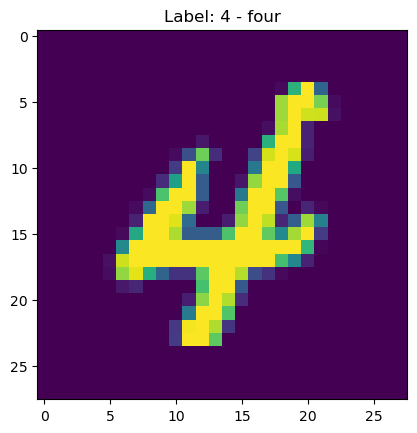

In [8]:
plt.imshow(X_sample.permute(1,2,0))
plt.title(f"Label: {training_data.classes[y_sample]}")
plt.show()

In [9]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

In [10]:
def train(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
  history = {"train_losses": [], "train_metrics": [], "valid_losses": [], "valid_metrics": []}
  for epoch in range(n_epochs):
    total_loss = 0.
    total_vloss = 0.
    metric.reset()
    model.train()
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      metric.update(y_pred, y_batch)
      
    for Xv_batch, yv_batch in valid_loader:
      Xv_batch, yv_batch = Xv_batch.to(device), yv_batch.to(device)
      yv_pred = model(Xv_batch)
      vloss = criterion(yv_pred, yv_batch)
      total_vloss += vloss.item()

    mean_loss = total_loss / len(train_loader)
    mean_vloss = total_vloss / len(valid_loader)
    history["train_losses"].append(mean_loss)
    history["valid_losses"].append(mean_vloss)
    history["train_metrics"].append(metric.compute().item())
    history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())
    print(f"Epoch {epoch + 1}/{n_epochs}, "
          f"train loss: {history['train_losses'][-1]:.4f}, "
          f"train metric: {history['train_metrics'][-1]:.4f}, "
          f"valid metric: {history['valid_metrics'][-1]:.4f}")
  return history

### B1

In [11]:
torch.manual_seed(rnd_seed)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same") # pre-filling some Conv2d params


# img size = 1*28*28
model = nn.Sequential(
  DefaultConv2d(in_channels=1, out_channels=64, kernel_size=2), nn.ReLU(),
  nn.MaxPool2d(kernel_size=2), # 1*14*14
  DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
  DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
  nn.MaxPool2d(kernel_size=2), # 1*7*7
  DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
  DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
  nn.MaxPool2d(kernel_size=2), # 1*3*3
  nn.Flatten(),
  nn.Linear(in_features=256*3*3, out_features=128), nn.ReLU(),
  nn.Dropout(0.5),
  nn.Linear(in_features=128, out_features=64), nn.ReLU(),
  nn.Dropout(0.5),
  nn.Linear(in_features=64, out_features=10),
).to(device)

### B2)

In [12]:
n_epochs = 10
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)

c:\Users\sachh\anaconda3\envs\ana\lib\site-packages\torch\nn\modules\conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv2d(


Epoch 1/10, train loss: 0.5514, train metric: 0.8245, valid metric: 0.9738
Epoch 2/10, train loss: 0.1834, train metric: 0.9511, valid metric: 0.9802
Epoch 3/10, train loss: 0.1272, train metric: 0.9686, valid metric: 0.9890
Epoch 4/10, train loss: 0.1009, train metric: 0.9753, valid metric: 0.9890
Epoch 5/10, train loss: 0.0779, train metric: 0.9807, valid metric: 0.9891
Epoch 6/10, train loss: 0.0631, train metric: 0.9846, valid metric: 0.9913
Epoch 7/10, train loss: 0.0595, train metric: 0.9855, valid metric: 0.9898
Epoch 8/10, train loss: 0.0492, train metric: 0.9879, valid metric: 0.9905
Epoch 9/10, train loss: 0.0460, train metric: 0.9887, valid metric: 0.9880
Epoch 10/10, train loss: 0.0423, train metric: 0.9888, valid metric: 0.9907


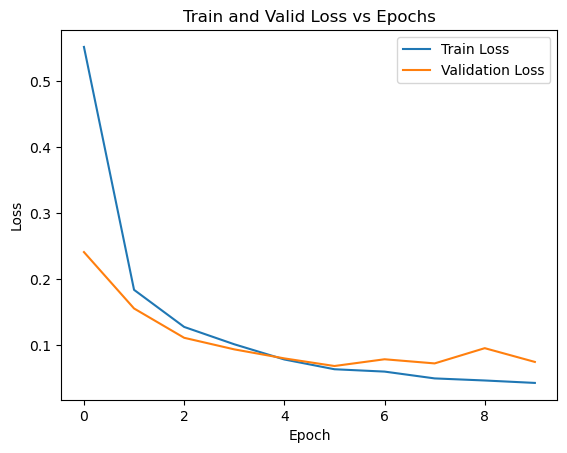

In [13]:
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['valid_losses'], label='Validation Loss')
plt.title('Train and Valid Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

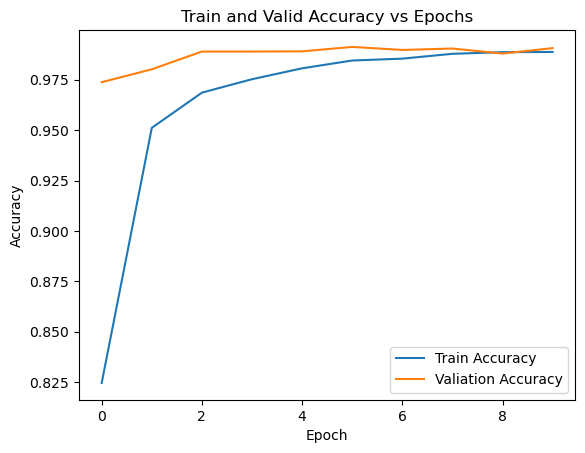

In [14]:
plt.plot(history['train_metrics'], label='Train Accuracy')
plt.plot(history['valid_metrics'], label='Valiation Accuracy')
plt.title('Train and Valid Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [15]:
print("test metric: ", evaluate_tm(model, test_loader, accuracy).item())

test metric:  0.9914000034332275


### B3) Data Augmentation

In [11]:
transform_augment = T.Compose([
  T.RandomAffine(degrees=15, translate=(0.1,0.1)),
  T.ToTensor(),
  T.ColorJitter(brightness=0.2, contrast=0.2),
  T.Normalize((0.1307,),(0.3081,))
])

transform_norm = T.Compose([
  T.ToTensor(),
  T.Normalize((0.1307,),(0.3081,))
])

train_augmented = datasets.MNIST(
    root="data",
    train=True,
    download=False,
    transform=transform_augment
)

test_and_valid_data = datasets.MNIST(
    root="data",
    train=False,
    download=False,
    transform=transform_norm
)

c:\Users\sachh\anaconda3\envs\ana\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [12]:
transform_augment = T.Compose([
  T.RandomAffine(degrees=15, translate=(0.1,0.1)),
  T.ToTensor(),
  T.ColorJitter(brightness=0.2, contrast=0.2),
  T.Normalize((0.1307,),(0.3081,))
])

transform_norm = T.Compose([
  T.ToTensor(),
  T.Normalize((0.1307,),(0.3081,))
])

train_augmented = datasets.MNIST(
    root="data",
    train=True,
    download=False,
    transform=transform_augment
)

test_and_valid_data = datasets.MNIST(
    root="data",
    train=False,
    download=False,
    transform=transform_norm
)

In [13]:
torch.manual_seed(rnd_seed)
test_data2, valid_data2 = torch.utils.data.random_split(test_and_valid_data, [8_000, 2_000])

In [14]:
torch.manual_seed(rnd_seed)
train_loader_augmented = DataLoader(train_augmented, batch_size=32, shuffle=True)
valid_loader2 = DataLoader(valid_data2, batch_size=32)
test_loader2 = DataLoader(test_data2, batch_size=32)

In [15]:
X_sample2, y_sample2 = train_augmented[23]
print(X_sample2.shape)
print(train_augmented.classes[y_sample2])
print(train_augmented.classes)

torch.Size([1, 28, 28])
1 - one
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


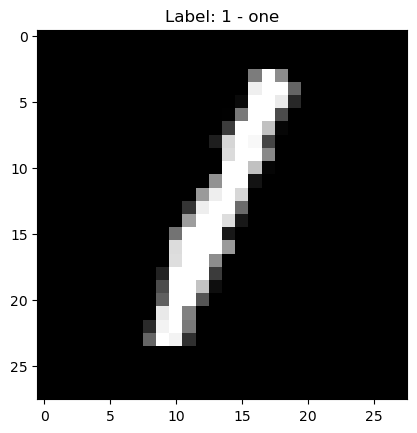

In [278]:
plt.imshow(X_sample2.permute(1,2,0), cmap="gray")
plt.title(f"Label: {train_augmented.classes[y_sample2]}")
plt.show()

In [17]:
X_sample, y_sample = train_data[23]
print(X_sample.shape)
print(training_data.classes[y_sample])
print(training_data.classes)

torch.Size([1, 28, 28])
1 - one
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


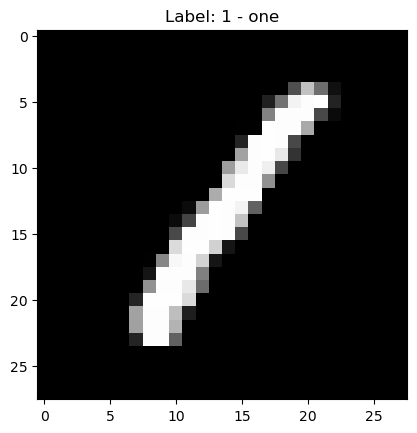

In [279]:
plt.imshow(X_sample.permute(1,2,0), cmap="gray")
plt.title(f"Label: {train_augmented.classes[y_sample]}")
plt.show()

In [19]:
torch.manual_seed(rnd_seed)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same") # pre-filling some Conv2d params


# img size = 1*28*28
model2 = nn.Sequential(
  DefaultConv2d(in_channels=1, out_channels=64, kernel_size=2), nn.ReLU(),
  nn.MaxPool2d(kernel_size=2), # 1*14*14
  DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
  DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
  nn.MaxPool2d(kernel_size=2), # 1*7*7
  DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
  DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
  nn.MaxPool2d(kernel_size=2), # 1*3*3
  nn.Flatten(),
  nn.Linear(in_features=256*3*3, out_features=128), nn.ReLU(),
  nn.Dropout(0.5),
  nn.Linear(in_features=128, out_features=64), nn.ReLU(),
  nn.Dropout(0.5),
  nn.Linear(in_features=64, out_features=10),
).to(device)

In [20]:
n_epochs = 10
optimizer = torch.optim.AdamW(model2 .parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history2 = train(model2, optimizer, xentropy, accuracy, train_loader_augmented, valid_loader2, n_epochs)

c:\Users\sachh\anaconda3\envs\ana\lib\site-packages\torch\nn\modules\conv.py:549: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\Convolution.cpp:1037.)
  return F.conv2d(


Epoch 1/10, train loss: 0.6464, train metric: 0.7873, valid metric: 0.9720
Epoch 2/10, train loss: 0.1969, train metric: 0.9501, valid metric: 0.9850
Epoch 3/10, train loss: 0.1453, train metric: 0.9654, valid metric: 0.9895
Epoch 4/10, train loss: 0.1155, train metric: 0.9728, valid metric: 0.9925
Epoch 5/10, train loss: 0.1030, train metric: 0.9759, valid metric: 0.9950
Epoch 6/10, train loss: 0.0942, train metric: 0.9779, valid metric: 0.9920
Epoch 7/10, train loss: 0.0918, train metric: 0.9793, valid metric: 0.9930
Epoch 8/10, train loss: 0.0802, train metric: 0.9816, valid metric: 0.9935
Epoch 9/10, train loss: 0.0796, train metric: 0.9825, valid metric: 0.9925
Epoch 10/10, train loss: 0.0766, train metric: 0.9831, valid metric: 0.9935


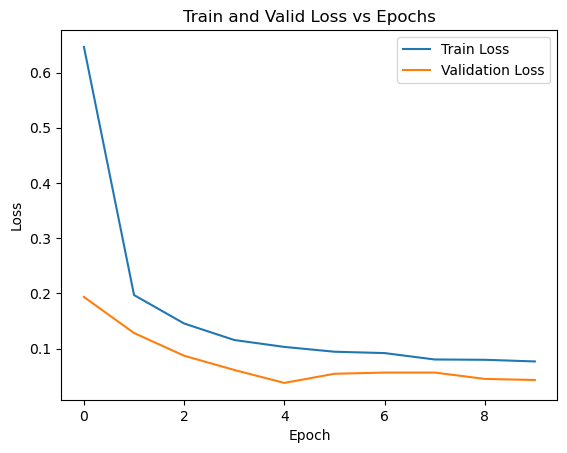

In [21]:
plt.plot(history2['train_losses'], label='Train Loss')
plt.plot(history2['valid_losses'], label='Validation Loss')
plt.title('Train and Valid Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

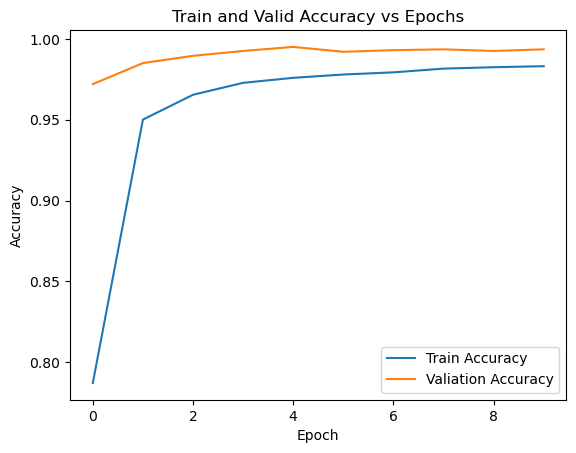

In [22]:
plt.plot(history2['train_metrics'], label='Train Accuracy')
plt.plot(history2['valid_metrics'], label='Valiation Accuracy')
plt.title('Train and Valid Accuracy vs Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [23]:
print("test metric: ", evaluate_tm(model2, test_loader2, accuracy).item())

test metric:  0.9933750033378601


In [24]:
model2

Sequential(
  (0): Conv2d(1, 64, kernel_size=(2, 2), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (4): ReLU()
  (5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (9): ReLU()
  (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (11): ReLU()
  (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (13): Flatten(start_dim=1, end_dim=-1)
  (14): Linear(in_features=2304, out_features=128, bias=True)
  (15): ReLU()
  (16): Dropout(p=0.5, inplace=False)
  (17): Linear(in_features=128, out_features=64, bias=True)
  (18): ReLU()
  (19): Dropout(p=0.5, inplace=False)
  (20): Linear(in_features=64, out_feat

In [25]:
from torchvision.models.feature_extraction import get_graph_node_names

train_nodes, eval_nodes = get_graph_node_names(model2)

In [26]:
from torchvision.models.feature_extraction import create_feature_extractor

# Map internal node names to custom output names
return_nodes = {
    #"12": "feature_map_1", # final conv layer outputs
    "13": "feature_map_2" # final conv layer flattened
}

# Create the new module
feature_extractor = create_feature_extractor(model2, return_nodes=return_nodes)

# testing functionality on random sample
img = torch.randn(1, 1, 28, 28).to(device)
out = feature_extractor(img)

print(torch.squeeze(out["feature_map_2"]).shape)

torch.Size([2304])


In [27]:
# running training images through inference mode to catch outputs

activation_loader = DataLoader(train_augmented, batch_size=1, shuffle=False)

train_activations_list = []
model2.eval()
with torch.no_grad():
  for X_batch, _ in activation_loader:
    X_batch = X_batch.to(device)
    out = feature_extractor(X_batch)
    out = out["feature_map_2"]
    train_activations_list.append(out)

final_activations_tensor = torch.cat(train_activations_list, dim=0)

print(final_activations_tensor.shape)

torch.Size([60000, 2304])


In [28]:
torch.save(final_activations_tensor, "activations.pt")

# Adversarial Attack

Using untargeted PGD:

- Optimization problem: $\max\limits_\delta L(C(x+\delta, w),t))$
- Constraints: 
  - $||\delta||_2 \leq \tau$
  -  $x+\delta \in [0,1], \space \forall x \in \Chi_{\text{advBatch}}$
- t $\neq$ ground truth label for $x$




In [281]:
import torch
import torch.nn.functional as F

def pgd_l2(model, images, labels, epsilon, alpha=0.1, num_iter=40):
    model.eval()

    x = images.detach()

    delta = torch.zeros_like(x, requires_grad=True)

    for _ in range(num_iter):

        if delta.grad is not None:
            delta.grad.zero_()

        outputs = model(x + delta)
        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        grad = delta.grad.detach()

        # L2 normalize gradient
        flat = grad.view(grad.size(0), -1)
        norm = torch.norm(flat, dim=1, keepdim=True)
        grad = grad / (norm.view(-1,1,1,1) + 1e-12)

        delta = delta + alpha * grad

        # L2 projection 
        delta_flat = delta.view(delta.size(0), -1)
        norms = torch.norm(delta_flat, dim=1, keepdim=True)

        factor = torch.clamp(norms / epsilon, min=1.0)
        delta = (delta_flat / factor).view_as(delta)

        delta = delta.detach().requires_grad_()

    adv = x + delta

    with torch.no_grad():
        preds = model(adv).argmax(1)

    return adv, preds

In [282]:
epsilons = [0.1, 0.25, 0.5, 1, 1.5, 2, 3, 4, 6, 8, 10]

In [283]:
from torch.utils.data import Subset
import random

correct_indices = []
target_count = 32

model2.eval()
accuracy.reset()  # reset the metric at the beginning
with torch.no_grad():
  for i, (X_batch, y_batch) in enumerate(test_loader2):
    out = model2(X_batch.to(device))
    _, pred = torch.max(out, dim=1)

    if pred[i] == y_batch[i]:
      correct_indices.append(i) # Save index

    if len(correct_indices) == target_count:
      break


In [284]:
random_indices = random.sample(range(len(correct_indices)), 10)

# Get values at those indices
sampled_indices = [correct_indices[i] for i in random_indices]

In [285]:
sampled_indices

[16, 8, 17, 15, 2, 31, 5, 21, 4, 7]

In [286]:
correct_subset = Subset(test_data2, sampled_indices)

adv_loader = DataLoader(correct_subset, batch_size = 32, shuffle=False)

In [287]:
accs = []

for eps in epsilons:
    correct, total = 0, 0
    alpha = eps/ 40

    for i, (imgs, labels) in enumerate(adv_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs = imgs.clone().detach()

        _, y_preds = pgd_l2(model2, imgs, labels, eps, alpha=alpha, num_iter=40)

        correct += (y_preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    print(f"Epsilon: {eps}, Test Accuracy: {acc:.4f}")
    accs.append(acc)

Epsilon: 0.1, Test Accuracy: 1.0000
Epsilon: 0.25, Test Accuracy: 1.0000
Epsilon: 0.5, Test Accuracy: 1.0000
Epsilon: 1, Test Accuracy: 1.0000
Epsilon: 1.5, Test Accuracy: 1.0000
Epsilon: 2, Test Accuracy: 1.0000
Epsilon: 3, Test Accuracy: 1.0000
Epsilon: 4, Test Accuracy: 0.9000
Epsilon: 6, Test Accuracy: 0.4000
Epsilon: 8, Test Accuracy: 0.1000
Epsilon: 10, Test Accuracy: 0.1000


C:\Users\sachh\AppData\Local\Temp\ipykernel_13008\1117793875.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


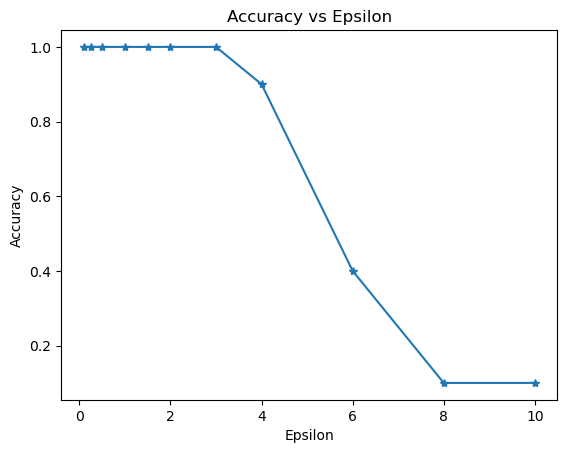

In [288]:
fig, ax = plt.subplots(nrows=1, ncols=1)  # create figure & 1 axis
ax.plot(epsilons, accs, "*-")
ax.set_title("Accuracy vs Epsilon")
ax.set_xlabel("Epsilon")
ax.set_ylabel("Accuracy")
fig.show()

C:\Users\sachh\AppData\Local\Temp\ipykernel_13008\2326332003.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


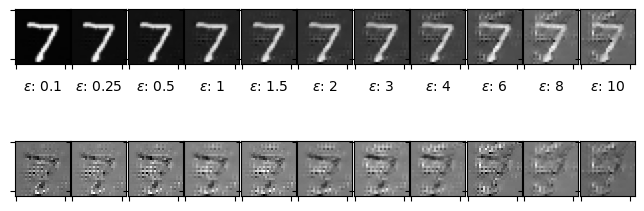

In [ ]:
for _, (imgs, labels) in enumerate(test_loader):
    imgs, labels = imgs.to(device), labels.to(device)
    imgs, labels = imgs.clone().detach().requires_grad_(True), labels.clone().detach()

    f = plt.figure(figsize=(8, 4))
    gs = f.add_gridspec(2, len(epsilons))
    gs.update(wspace=0.025, hspace=-0.25) 

    for i in range(len(epsilons)):
        eps = epsilons[i]
        alpha = eps/ 40
        ax1 = f.add_subplot(gs[0, i])
        ax2 = f.add_subplot(gs[1, i])
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, labels =  imgs.clone().detach().requires_grad_(True), labels.clone().detach()

        adv_imgs, _ = pgd_l2(model2, imgs, labels, epsilon=eps, alpha=alpha, num_iter=40)
        
        img, adv_img = imgs[0], adv_imgs[0]
        img, adv_img = img.cpu().detach(), adv_img.cpu().detach()
        img, adv_img = img.numpy(), adv_img.numpy()
        noise = adv_img - img

        ax1.imshow(adv_img.squeeze(), cmap="gray")
        ax1.set_xlabel(f"$\epsilon$: {eps}")
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])

        ax2.imshow(noise.squeeze(), cmap="gray")
        ax2.set_xticklabels([])
        ax2.set_yticklabels([])

    f.show()
    break

C:\Users\sachh\AppData\Local\Temp\ipykernel_13008\2986859087.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


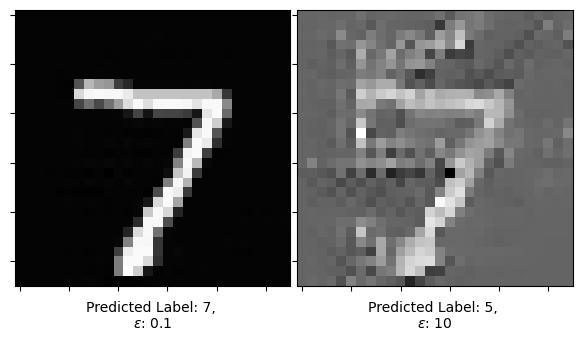

In [314]:
for _, (imgs, labels) in enumerate(test_loader):
    imgs, labels = imgs.to(device), labels.to(device)
    imgs, labels = imgs.clone().detach().requires_grad_(True), labels.clone().detach()

    f = plt.figure(figsize=(40, 20))
    gs = f.add_gridspec(2, len(epsilons))
    gs.update(wspace=0.025, hspace=-0.25) 

    for i, eps in enumerate([0.1,10]):
        alpha = eps/ 40
        ax1 = f.add_subplot(gs[0, i])
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, labels =  imgs.clone().detach().requires_grad_(True), labels.clone().detach()

        adv_imgs, lab_adv = pgd_l2(model2, imgs, labels, epsilon=eps, alpha=alpha, num_iter=40)
        
        img, adv_img = imgs[0], adv_imgs[0]
        img, adv_img = img.cpu().detach(), adv_img.cpu().detach()
        img, adv_img = img.numpy(), adv_img.numpy()
        noise = adv_img - img

        ax1.imshow(adv_img.squeeze(), cmap="gray")
        ax1.set_xlabel(f"Predicted Label: {lab_adv[0].item()}, \n$\epsilon$: {eps}")
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])
    f.show()
    break